In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import re

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7.5,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
})

In [31]:
SIZE_ORDER = ['Small', 'Medium', 'Large']
SIZE_COLORS = {'Small': '#66c2a5', 'Medium': '#fc8d62', 'Large': '#8da0cb'}

def assign_size_category(df):
    """Assign size category based on adapter type and rank/svecs."""
    df = df.copy()

    def _get_size(row):
        atype = row['adapter_type']
        if atype == 'vera':
            return 'Small'
        elif atype in ('lora', 'dora'):
            r = row.get('rank', 0)
            if r <= 1:
                return 'Small'
            elif r <= 8:
                return 'Medium'
            else:
                return 'Large'
        elif atype == 'uiortholora':
            sv = row.get('svecs', 0)
            if pd.isna(sv):
                sv = 0
            if sv <= 32:
                return 'Small'
            elif sv < 512:
                return 'Medium'
            else:
                return 'Large'
        return 'Medium'

    df['size_category'] = df.apply(_get_size, axis=1)
    return df

In [32]:
def get_best_per_size(merged_mmlu, merged_bigbench, acc_threshold,
                      neg_shift_col='negative_shift_score',
                      task_acc_col='accuracy',
                      mmlu_col='mmlu_acc',
                      bigbench_col='mean_accuracy'):
    """
    For each adapter × size, find:
      - lowest negative shift (among configs with acc >= threshold)
      - highest avg general accuracy (among configs with acc >= threshold)
    Returns a DataFrame with columns:
      adapter_type, size_category, best_neg_shift, best_avg_general
    """
    results = []

    # Use whichever source has neg_shift
    if neg_shift_col in merged_mmlu.columns:
        src_neg = merged_mmlu
    elif neg_shift_col in merged_bigbench.columns:
        src_neg = merged_bigbench
    else:
        src_neg = pd.DataFrame()

    # Get all adapters
    adapters = set()
    if not merged_mmlu.empty:
        adapters |= set(merged_mmlu['adapter_type'].unique())
    if not merged_bigbench.empty:
        adapters |= set(merged_bigbench['adapter_type'].unique())

    for adapter in sorted(adapters):
        # --- Negative shift: best = lowest ---
        neg_sub = pd.DataFrame()
        if not src_neg.empty:
            neg_sub = src_neg[
                (src_neg['adapter_type'] == adapter) &
                (src_neg[task_acc_col] >= acc_threshold)
            ].dropna(subset=[neg_shift_col])
            neg_sub = assign_size_category(neg_sub)

        # --- Avg general accuracy: best = highest ---
        mmlu_sub = pd.DataFrame()
        bb_sub = pd.DataFrame()
        if not merged_mmlu.empty:
            mmlu_sub = merged_mmlu[
                (merged_mmlu['adapter_type'] == adapter) &
                (merged_mmlu[task_acc_col] >= acc_threshold)
            ].dropna(subset=[mmlu_col])
            mmlu_sub = assign_size_category(mmlu_sub)
        if not merged_bigbench.empty:
            bb_sub = merged_bigbench[
                (merged_bigbench['adapter_type'] == adapter) &
                (merged_bigbench[task_acc_col] >= acc_threshold)
            ].dropna(subset=[bigbench_col])
            bb_sub = assign_size_category(bb_sub)

        # Average MMLU + BigBench per merge_key
        avg_parts = []
        if not mmlu_sub.empty:
            m = mmlu_sub[['merge_key', mmlu_col, 'size_category']].copy()
            m = m.rename(columns={mmlu_col: 'general_acc'})
            avg_parts.append(m)
        if not bb_sub.empty:
            b = bb_sub[['merge_key', bigbench_col, 'size_category']].copy()
            b = b.rename(columns={bigbench_col: 'general_acc'})
            avg_parts.append(b)

        if avg_parts:
            avg_df = pd.concat(avg_parts, ignore_index=True)
            avg_df = (avg_df.groupby('merge_key')
                      .agg(avg_general_acc=('general_acc', 'mean'),
                           size_category=('size_category', 'first'))
                      .reset_index())
        else:
            avg_df = pd.DataFrame()

        for size in SIZE_ORDER:
            row = {'adapter_type': adapter, 'size_category': size}

            # Best neg shift for this size
            if not neg_sub.empty:
                ns = neg_sub[neg_sub['size_category'] == size]
                row['best_neg_shift'] = ns[neg_shift_col].min() if not ns.empty else np.nan
            else:
                row['best_neg_shift'] = np.nan

            # Best avg general acc for this size
            if not avg_df.empty:
                ag = avg_df[avg_df['size_category'] == size]
                row['best_avg_general'] = ag['avg_general_acc'].max() if not ag.empty else np.nan
            else:
                row['best_avg_general'] = np.nan

            # Only include if at least one metric exists
            if not (pd.isna(row['best_neg_shift']) and pd.isna(row['best_avg_general'])):
                results.append(row)

    return pd.DataFrame(results)

In [33]:
def plot_size_bars(
    merged_mmlu, merged_bigbench,
    model, task,
    acc_threshold=0.99,
    neg_shift_col='negative_shift_score',
    task_acc_col='accuracy',
    mmlu_col='mmlu_acc',
    bigbench_col='mean_accuracy',
    figsize=(5.5, 3.8),
    save_path=None,
    dpi=300
):
    task_label = task.replace('qa', 'QA').replace('hotpot', 'HotPot').replace('trivia', 'Trivia')
    model_label = model.replace('gemma-12b', 'Gemma-3-it 12B').replace('llama-3b', 'Llama-3.2 3B')

    adapter_display = {
        'lora': 'LoRA', 'dora': 'DoRA',
        'uiortholora': 'UIorthoLoRA', 'vera': 'VeRA',
    }

    best_df = get_best_per_size(
        merged_mmlu, merged_bigbench, acc_threshold,
        neg_shift_col, task_acc_col, mmlu_col, bigbench_col
    )

    if best_df.empty:
        print("No data above threshold.")
        return

    all_adapters = sorted(best_df['adapter_type'].unique())

    # Build y-positions: group bars by adapter, skip missing sizes
    y_positions = []
    y_labels = []
    y = 0
    bar_height = 0.65
    adapter_centers = {}

    for ai, adapter in enumerate(all_adapters):
        adf = best_df[best_df['adapter_type'] == adapter]
        sizes_present = [s for s in SIZE_ORDER if s in adf['size_category'].values]
        start_y = y
        for si, size in enumerate(sizes_present):
            y_positions.append((y, adapter, size))
            y_labels.append(size[0])
            y += 1
        adapter_centers[adapter] = (start_y + y - 1) / 2
        y += 0.8  # gap between adapters

    fig, axes = plt.subplots(1, 2, figsize=figsize,
                              gridspec_kw={'wspace': 0.15})

    fig.suptitle(f'{model_label} — {task_label}  (acc ≥ {acc_threshold})',
                 fontsize=11, fontweight='bold')

    metrics = [
        ('best_neg_shift', 'Negative Shift', False),
        ('best_avg_general', 'Avg General Accuracy', True),
    ]

    for col_i, (metric, xlabel, higher_better) in enumerate(metrics):
        ax = axes[col_i]
        ax.grid(True, axis='x', linestyle='-', linewidth=0.3, alpha=0.35, color='#bbbbbb')

        for yp, adapter, size in y_positions:
            row = best_df[(best_df['adapter_type'] == adapter) &
                          (best_df['size_category'] == size)]
            if row.empty:
                continue
            val = row[metric].values[0]
            if pd.isna(val):
                continue
            ax.barh(yp, val, height=bar_height,
                    color=SIZE_COLORS[size], edgecolor='#444444',
                    linewidth=0.4, zorder=3)
            fmt = f'{val:.0f}' if metric == 'best_neg_shift' else f'{val:.3f}'
            ax.text(val, yp, f' {fmt}', va='center', ha='left',
                    fontsize=6.5, color='#333')

        # Y-axis: just size letters on left panel, nothing on right
        all_y = [yp for yp, _, _ in y_positions]
        if col_i == 0:
            size_labels = [size[0] for _, _, size in y_positions]
            ax.set_yticks(all_y)
            ax.set_yticklabels(size_labels, fontsize=7.5)
        else:
            ax.set_yticks(all_y)
            ax.set_yticklabels([])

        ax.invert_yaxis()
        ax.set_title(xlabel, fontsize=9, pad=4)

        # Add some right margin for value labels
        xlim = ax.get_xlim()
        ax.set_xlim(xlim[0], xlim[1] * 1.12)

    # Horizontal separator lines between adapter groups
    for col_i in range(2):
        ax = axes[col_i]
        for ai in range(len(all_adapters) - 1):
            adapter = all_adapters[ai]
            next_adapter = all_adapters[ai + 1]
            last_y = None
            first_next_y = None
            for yp, a, s in y_positions:
                if a == adapter:
                    last_y = yp
                if a == next_adapter and first_next_y is None:
                    first_next_y = yp
            if last_y is not None and first_next_y is not None:
                mid = (last_y + first_next_y) / 2
                ax.axhline(mid, color='#cccccc', linewidth=0.5, linestyle='-')

    # Adapter labels on right side (rotated, like scatter plot)
    for adapter, center_y in adapter_centers.items():
        display_name = adapter_display.get(adapter, adapter)
        axes[1].annotate(
            display_name, xy=(1.03, center_y),
            xycoords=('axes fraction', 'data'),
            fontsize=8, fontweight='bold', rotation=-90,
            ha='left', va='center'
        )

    # Legend at bottom center
    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=SIZE_COLORS[s],
                       edgecolor='#444444', linewidth=0.4)
        for s in SIZE_ORDER
    ]
    fig.legend(
        legend_handles, SIZE_ORDER, title='Size', title_fontsize=7,
        loc='lower center', bbox_to_anchor=(0.5, -0.02),
        fontsize=6.5, frameon=True, fancybox=False,
        edgecolor='#cccccc', framealpha=0.92,
        handletextpad=0.3, borderpad=0.3,
        labelspacing=0.2, ncol=3
    )

    fig.tight_layout(rect=[0.0, 0.05, 0.95, 0.95])

    if save_path:
        import os
        os.makedirs(save_path, exist_ok=True)
        fname = f"{save_path}/{model}_{task}_size_bars.pdf"
        fig.savefig(fname, dpi=dpi)
        print(f"Saved: {fname}")

    plt.show()

In [34]:
def extract_metadata(df, name_col='model_path'):
    df = df.copy()
    
    if 'peft_method' in df.columns:
        df['adapter_type'] = df['peft_method'].fillna('')
    else:
        df['adapter_type'] = ''

    def get_adapter(row):
        val = str(row.get('adapter_type', '')).lower()
        name = str(row[name_col]).lower()
        if val in ['lora', 'vera', 'uiortholora', 'dora']:
            return val
        if 'uiortho' in name: return 'uiortholora'
        if 'dora' in name: return 'dora'
        if 'vera' in name: return 'vera'
        if 'lora' in name: return 'lora'
        return 'unknown'

    df['adapter_type'] = df.apply(get_adapter, axis=1)

    def get_lr(row):
        if 'learning_rate' in row and pd.notnull(row['learning_rate']):
            return float(row['learning_rate'])
        if 'lr' in row and pd.notnull(row['lr']):
            try: return float(row['lr'])
            except (ValueError, TypeError): pass
        match = re.search(r'lr([\de.-]+)', str(row[name_col]))
        if match:
            try: return float(match.group(1))
            except: return np.nan
        return np.nan

    df['lr'] = df.apply(get_lr, axis=1)

    regex_pattern = r'_(?:s|sv)(\d+)_(?:v|svec)(\d+)'

    def get_svals(row):
        m = re.search(regex_pattern, str(row[name_col]))
        return int(m.group(1)) if m else np.nan

    def get_svecs(row):
        m = re.search(regex_pattern, str(row[name_col]))
        return int(m.group(2)) if m else np.nan

    df['svals'] = df.apply(get_svals, axis=1)
    df['svecs'] = df.apply(get_svecs, axis=1)

    def get_rank(row):
        if 'rank' in row and pd.notnull(row['rank']):
            try: return int(float(row['rank']))
            except (ValueError, TypeError): pass
        name = str(row[name_col])
        m_sv = re.search(regex_pattern, name)
        if m_sv: return int(m_sv.group(1))
        m_r = re.search(r'_r(\d+)', name)
        if m_r: return int(m_r.group(1))
        return 0

    df['rank'] = df.apply(get_rank, axis=1)
    return df


def align_and_merge(df_task, df_general, general_name_col='model_name', 
                    task_name_col='raw_adapter_name', suffixes=('_task', '_gen')):
    df_general = df_general.copy()
    df_general['merge_key'] = (
        df_general[general_name_col].str.replace('models/', '', n=1).str.split('/').str[-1]
    )
    df_task = df_task.copy()
    df_task['merge_key'] = (
        df_task[task_name_col].str.replace('models/', '', n=1).str.split('/').str[-1]
    )
    merged = pd.merge(df_task, df_general, on='merge_key', suffixes=suffixes)
    merged = extract_metadata(merged, name_col='merge_key')
    print(f"Merged rows: {len(merged)} "
          f"(task: {len(df_task)}, general: {len(df_general)}, "
          f"unmatched task: {len(df_task) - len(merged)})")
    return merged


def load_and_merge(model, task, threshold='0.8', filter_fn=None):
    file_path = f'adapters_results/{task}/threshold_{threshold}/{model}.csv'
    mmlu_path = f'adapters_results/{task}/mmlu_summary.csv'
    bigbench_path = f'adapters_results/{task}/bigbench_summary.csv'
    df_task = pd.read_csv(file_path)
    df_mmlu = pd.read_csv(mmlu_path)
    df_bigbench = pd.read_csv(bigbench_path)
    print(f"=== {model} / {task} ===")
    merged_mmlu = align_and_merge(df_task, df_mmlu, general_name_col='model_name')
    merged_bigbench = align_and_merge(df_task, df_bigbench, general_name_col='model_path')
    if filter_fn:
        merged_mmlu = filter_fn(merged_mmlu)
        merged_bigbench = filter_fn(merged_bigbench)
        print(f"After filter: MMLU={len(merged_mmlu)}, BigBench={len(merged_bigbench)}")
    return merged_mmlu, merged_bigbench


final_filter = lambda df: df
gemma_trivia_mmlu, gemma_trivia_bb = load_and_merge('gemma-12b', 'triviaqa', filter_fn=final_filter)
gemma_hotpot_mmlu, gemma_hotpot_bb = load_and_merge('gemma-12b', 'hotpotqa', filter_fn=final_filter)
llama_trivia_mmlu, llama_trivia_bb = load_and_merge('llama-3b', 'triviaqa', filter_fn=final_filter)
llama_hotpot_mmlu, llama_hotpot_bb = load_and_merge('llama-3b', 'hotpotqa', filter_fn=final_filter)

=== gemma-12b / triviaqa ===
Merged rows: 208 (task: 153, general: 283, unmatched task: -55)
Merged rows: 220 (task: 153, general: 296, unmatched task: -67)
After filter: MMLU=208, BigBench=220
=== gemma-12b / hotpotqa ===
Merged rows: 253 (task: 236, general: 351, unmatched task: -17)
Merged rows: 262 (task: 236, general: 364, unmatched task: -26)
After filter: MMLU=253, BigBench=262
=== llama-3b / triviaqa ===
Merged rows: 201 (task: 162, general: 283, unmatched task: -39)
Merged rows: 207 (task: 162, general: 296, unmatched task: -45)
After filter: MMLU=201, BigBench=207
=== llama-3b / hotpotqa ===
Merged rows: 176 (task: 141, general: 351, unmatched task: -35)
Merged rows: 184 (task: 141, general: 364, unmatched task: -43)
After filter: MMLU=176, BigBench=184


/tmp/ipykernel_1567224/146131975.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.0, 0.05, 0.95, 0.95])


Saved: ./graphs/gemma-hotpot-size/gemma-12b_hotpotqa_size_bars.pdf


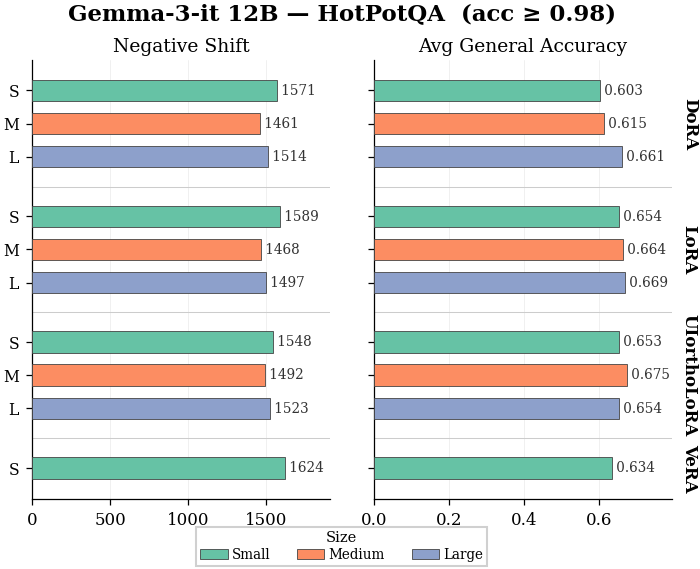

In [35]:
plot_size_bars(gemma_hotpot_mmlu, gemma_hotpot_bb, 'gemma-12b', 'hotpotqa', acc_threshold=0.98, save_path="./graphs/gemma-hotpot-size")
# plot_size_bars(gemma_trivia_mmlu, gemma_trivia_bb, 'gemma-12b', 'triviaqa', acc_threshold=0.98)
# plot_size_bars(llama_hotpot_mmlu, llama_hotpot_bb, 'llama-3b', 'hotpotqa', acc_threshold=0.98)
# plot_size_bars(llama_trivia_mmlu, llama_trivia_bb, 'llama-3b', 'triviaqa', acc_threshold=0.98)